## 1. Import Libraries and Setup

In [2]:
import math
import matplotlib.pyplot as plt
import autograd.numpy as np
import autograd.numpy as sqrt
from autograd.numpy.linalg import norm
from autograd.numpy.linalg import inv
from autograd import jacobian
from autograd.test_util import check_grads
from control import dlqr
import time
from scipy.spatial.transform import Rotation as spRot
from scipy.linalg import solve_discrete_are
np.set_printoptions(precision=4, suppress=True)

# Quadrotor physical parameters
mass = 0.035  # kg
J = np.array([[16.6e-6, 0.83e-6, 0.72e-6],
              [0.83e-6, 16.6e-6, 1.8e-6],
              [0.72e-6, 1.8e-6, 29.3e-6]])  # kg*m^2
g = 9.81  # m/s^2
thrustToTorque = 0.0008
el = 0.046/1.414213562  # m
scale = 65535
kt = 2.245365e-6*scale
km = kt*thrustToTorque

# Control parameters
freq = 50.0  # Hz
h = 1/freq   # sampling time
Nx1 = 13     # full state dimension (with quaternions)
Nx = 12      # reduced state dimension (error coordinates)
Nu = 4       # control dimension

# Figure-8 trajectory parameters
A_fig8 = 0.5
w_fig8 = 2*np.pi/7

In [ ]:
# Generate comprehensive visualization
def create_comprehensive_plots(results_list, T_sim, labels=None, colors=None):
    """Create comprehensive comparison plots for flat figure-8 trajectory.
    
    Args:
        results_list: list of tuples, each (x_traj, u_traj, iter_list, status_list)
        T_sim: total simulation time
        labels: optional list of labels (same length as results_list)
        colors: optional list of colors (same length as results_list)
        
    Returns:
        errors_xy: list of position error arrays for each controller
        efforts: list of control effort arrays for each controller
    """
    
    # Time vectors
    n_steps = results_list[0][0].shape[1]
    t = np.linspace(0, T_sim, n_steps)
    t_u = np.linspace(0, T_sim, results_list[0][1].shape[1])
    
    # Reference trajectory
    x_ref = np.array([generate_figure8_reference(t_i) for t_i in t]).T
    
    # Defaults for labels/colors
    if labels is None:
        labels = [f"Controller {i+1}" for i in range(len(results_list))]
    if colors is None:
        base_colors = ['b','r','g','m','c','y','tab:orange','tab:purple']
        colors = [base_colors[i % len(base_colors)] for i in range(len(results_list))]
    
    fig = plt.figure(figsize=(18, 12))
    
    # 1) 2D Trajectory (X-Y)
    ax1 = plt.subplot(2, 4, 1)
    plt.plot(x_ref[0, :], x_ref[1, :], 'k--', linewidth=2, alpha=0.7, label='Reference')
    for (x_traj, _, _, _), lab, col in zip(results_list, labels, colors):
        plt.plot(x_traj[0, :], x_traj[1, :], '-', linewidth=2, label=lab, color=col)
    plt.xlabel('X Position [m]')
    plt.ylabel('Y Position [m]')
    plt.title('Flat Figure-8 Trajectory Comparison (X-Y)')
    plt.axis('equal')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 2) X Position vs Time
    ax2 = plt.subplot(2, 4, 2)
    plt.plot(t, x_ref[0, :], 'k--', linewidth=2, alpha=0.7, label='Reference')
    for (x_traj, _, _, _), lab, col in zip(results_list, labels, colors):
        plt.plot(t, x_traj[0, :], '-', linewidth=2, label=lab, color=col)
    plt.xlabel('Time [s]')
    plt.ylabel('X Position [m]')
    plt.title('X Position Tracking')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 3) Y Position vs Time
    ax3 = plt.subplot(2, 4, 3)
    plt.plot(t, x_ref[1, :], 'k--', linewidth=2, alpha=0.7, label='Reference')
    for (x_traj, _, _, _), lab, col in zip(results_list, labels, colors):
        plt.plot(t, x_traj[1, :], '-', linewidth=2, label=lab, color=col)
    plt.xlabel('Time [s]')
    plt.ylabel('Y Position [m]')
    plt.title('Y Position Tracking')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 4) Position Tracking Error (X-Y)
    ax4 = plt.subplot(2, 4, 4)
    for (x_traj, _, _, _), lab, col in zip(results_list, labels, colors):
        # Calculate position error (X-Y)
        err_xy = np.linalg.norm(x_traj[[0,1], :] - x_ref[[0,1], :], axis=0)
        plt.plot(t, err_xy, '-', linewidth=2, label=lab, color=col)
    plt.xlabel('Time [s]')
    plt.ylabel('Position Error [m]')
    plt.title('Position Tracking Error (X-Y)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    
    # 5) Control Inputs
    ax5 = plt.subplot(2, 4, 5)
    for (_, u_traj, _, _), lab, col in zip(results_list, labels, colors):
        for i in range(Nu):
            plt.plot(t_u, u_traj[i, :], '-', alpha=0.7, linewidth=1, color=col)
    plt.axhline(y=uhover[0], color='k', linestyle='--', alpha=0.5, label='Hover')
    plt.xlabel('Time [s]')
    plt.ylabel('Control Input')
    plt.title('Control Inputs')
    plt.grid(True, alpha=0.3)
    
    # 6) Control Effort
    ax6 = plt.subplot(2, 4, 6)
    for (_, u_traj, _, _), lab, col in zip(results_list, labels, colors):
        effort = np.linalg.norm(u_traj - uhover.reshape(-1,1), axis=0)
        plt.plot(t_u, effort, '-', linewidth=2, label=lab, color=col)
    plt.xlabel('Time [s]')
    plt.ylabel('Control Effort')
    plt.title('Control Effort (Deviation from Hover)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 7) ADMM Iterations
    ax7 = plt.subplot(2, 4, 7)
    for (_, _, iters, _), lab, col in zip(results_list, labels, colors):
        plt.plot(t_u, iters, '-', linewidth=2, label=lab, color=col)
    plt.xlabel('Time [s]')
    plt.ylabel('ADMM Iterations')
    plt.title('ADMM Convergence')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 8) 3D Trajectory (X-Y-Time)
    ax8 = plt.subplot(2, 4, 8, projection='3d')
    ax8.plot(x_ref[0, :], x_ref[1, :], t, 'k--', linewidth=2, alpha=0.7, label='Reference')
    for (x_traj, _, _, _), lab, col in zip(results_list, labels, colors):
        ax8.plot(x_traj[0, :], x_traj[1, :], t, '-', linewidth=2, label=lab, color=col)
    ax8.set_xlabel('X [m]')
    ax8.set_ylabel('Y [m]')
    ax8.set_zlabel('Time [s]')
    ax8.set_title('3D Trajectory (X-Y-Time)')
    ax8.legend(loc='upper left')
    
    plt.tight_layout()
    plt.savefig('controller_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Performance summary table
    print("\nPerformance Summary:")
    print("-" * 80)
    print(f"{'Controller':<20} {'Type':<10} {'Avg Error':<12} {'Max Error':<12} {'Avg Effort':<12} {'Avg Iters':<10}")
    print("-" * 80)
    
    # Calculate and return metrics
    errors_xy = []
    efforts = []
    controller_metrics = []
    
    for i, ((x_traj, u_traj, iters, _), lab) in enumerate(zip(results_list, labels)):
        # Calculate error and effort metrics
        err_xy = np.linalg.norm(x_traj[[0,1], :] - x_ref[[0,1], :], axis=0)
        effort = np.linalg.norm(u_traj - uhover.reshape(-1,1), axis=0)
        
        errors_xy.append(err_xy)
        efforts.append(effort)
        
        # Determine controller type from iterations (approximation)
        is_tinympc = np.mean(iters) > 1.5
        ctrl_type = "TinyMPC" if is_tinympc else "LQR"
        
        # Print summary stats
        print(f"{lab:<20} {ctrl_type:<10} {np.mean(err_xy):<12.4f} {np.max(err_xy):<12.4f} "
              f"{np.mean(effort):<12.4f} {np.mean(iters):<10.1f}")
        
        # Store metrics for ranking
        controller_metrics.append({
            'name': lab,
            'type': ctrl_type,
            'avg_error': np.mean(err_xy),
            'max_error': np.max(err_xy),
            'avg_effort': np.mean(effort),
            'avg_iters': np.mean(iters)
        })
    
    print("-" * 80)
    
    # Rank controllers by average error
    print("\nRanking by Average Error:")
    for i, ctrl in enumerate(sorted(controller_metrics, key=lambda x: x['avg_error'])):
        print(f"{i+1}. {ctrl['name']} ({ctrl['type']}): {ctrl['avg_error']:.4f}")
    return errors_xy, efforts

## 2. Quadrotor Dynamics and Reference Trajectory

In [4]:
def generate_figure8_reference(t):
    """Generate flat figure-8 reference (X-Y plane) with smooth start"""
    # Smooth start factor (ramps up in first second)
    smooth_start = min(t/1.0, 1.0)
    
    x_ref = np.zeros(12)
    
    # Positions with smooth start - FLAT figure-8 in X-Y plane
    x_ref[0] = A_fig8 * np.sin(w_fig8*t) * smooth_start          # X position
    x_ref[1] = A_fig8 * np.sin(2*w_fig8*t)/2 * smooth_start     # Y position (instead of Z)
    x_ref[2] = 0.0  # Z position stays at zero (flat trajectory)
    
    # Velocities (derivatives with smooth start)
    x_ref[6] = A_fig8 * w_fig8 * np.cos(w_fig8*t) * smooth_start      # X velocity
    x_ref[7] = A_fig8 * w_fig8 * np.cos(2*w_fig8*t) * smooth_start    # Y velocity (instead of Z)
    x_ref[8] = 0.0  # Z velocity stays at zero
    
    # Zero attitude and angular velocity
    x_ref[3:6] = np.zeros(3)
    x_ref[9:12] = np.zeros(3)
    
    return x_ref

# Quaternion functions
def hat(v):
    return np.array([[0, -v[2], v[1]],
                     [v[2], 0, -v[0]],
                     [-v[1], v[0], 0.0]])

def L(q):
    s = q[0]
    v = q[1:4]
    up = np.hstack([s, -v])
    down = np.hstack([v.reshape(3,1), s*np.eye(3) + hat(v)])
    L = np.vstack([up,down])
    return L

T = np.diag([1.0, -1, -1, -1])
H = np.vstack([np.zeros((1,3)), np.eye(3)])

def qtoQ(q):
    return H.T @ T @ L(q) @ T @ L(q) @ H

def G(q):
    return L(q) @ H

def rptoq(phi):
    return (1./math.sqrt(1+phi.T @ phi)) * np.hstack([1, phi])

def qtorp(q):
    return q[1:4]/q[0]

def E(q):
    up = np.hstack([np.eye(3), np.zeros((3,3)), np.zeros((3,6))])
    mid = np.hstack([np.zeros((4,3)), G(q), np.zeros((4,6))])
    down = np.hstack([np.zeros((6,3)), np.zeros((6,3)), np.eye(6)])
    E = np.vstack([up, mid, down])
    return E


In [ ]:
def quad_dynamics(x, u):
    """Quadrotor dynamics in 13D state space"""
    r = x[0:3]
    q = x[3:7]/norm(x[3:7])
    v = x[7:10]
    omg = x[10:13]
    Q = qtoQ(q)

    dr = v
    dq = 0.5*L(q)@H@omg
    dv = np.array([0, 0, -g]) + (1/mass)*Q@np.array([[0, 0, 0, 0], 
                                                     [0, 0, 0, 0], 
                                                     [kt, kt, kt, kt]])@u
    domg = inv(J)@(-hat(omg)@J@omg + 
                   np.array([[-el*kt, -el*kt, el*kt, el*kt], 
                            [-el*kt, el*kt, el*kt, -el*kt], 
                            [-km, km, -km, km]])@u)

    return np.hstack([dr, dq, dv, domg])

def quad_dynamics_rk4(x, u):
    """RK4 integration of quadrotor dynamics"""
    f1 = quad_dynamics(x, u)
    f2 = quad_dynamics(x + 0.5*h*f1, u)
    f3 = quad_dynamics(x + 0.5*h*f2, u)
    f4 = quad_dynamics(x + h*f3, u)
    xn = x + (h/6.0)*(f1 + 2*f2 + 2*f3 + f4)
    xnormalized = xn[3:7]/norm(xn[3:7])
    return np.hstack([xn[0:3], xnormalized, xn[7:13]])

def delta_x_quat(x_curr, t):
    """Compute error between current state and reference"""
    x_ref = generate_figure8_reference(t)
    
    # Current quaternion
    q = x_curr[3:7]
    
    # Reference quaternion (hover)
    q_ref = np.array([1.0, 0.0, 0.0, 0.0])
    
    # Quaternion error
    phi = qtorp(L(q_ref).T @ q)
    
    # Full state error (12 dimensions)
    delta_x = np.hstack([
        x_curr[0:3] - x_ref[0:3],    # position error
        phi,                          # attitude error (3 components)
        x_curr[7:10] - x_ref[6:9],   # velocity error
        x_curr[10:13] - x_ref[9:12]  # angular velocity error
    ])
    return delta_x

print("Quadrotor dynamics implemented!")

# Setup nominal equilibrium point
rg = np.array([0.0, 0, 0.0])
qg = np.array([1.0, 0, 0, 0])
vg = np.zeros(3)
omgg = np.zeros(3)
xg = np.hstack([rg, qg, vg, omgg])
uhover = (mass*g/kt/4)*np.ones(4)

print(f"Hover control input: {uhover}")
print(f"Nominal state dimension: {len(xg)}")

Quadrotor dynamics implemented!
Hover control input: [0.5833 0.5833 0.5833 0.5833]
Nominal state dimension: 13


## 3. Enhanced TinyMPC Class with Manual K Specification

In [6]:
class TinyMPC:
    """Enhanced TinyMPC with manual K matrix specification capability"""
    
    def __init__(self, input_data, Nsteps, K_manual=None):
        self.cache = {}
        self.cache['rho'] = input_data['rho']
        self.cache['A'] = input_data['A']
        self.cache['B'] = input_data['B']
        self.cache['Q'] = input_data['Q']
        self.cache['R'] = input_data['R']
        
        # Initialize with manual K if provided, otherwise compute iteratively
        if K_manual is not None:
            self.cache['Kinf'] = K_manual
            self.compute_cache_terms_with_manual_K()
            print(f"TinyMPC initialized with manual K matrix (norm: {np.linalg.norm(K_manual):.4f})")
        else:
            self.compute_cache_terms()
            print(f"TinyMPC initialized with computed K_inf (norm: {np.linalg.norm(self.cache['Kinf']):.4f})")
        
        self.set_tols_iters()
        self.x_prev = np.zeros((self.cache['A'].shape[0], Nsteps))
        self.u_prev = np.zeros((self.cache['B'].shape[1], Nsteps))
        self.N = Nsteps

    def compute_cache_terms(self):
        """Standard TinyMPC computation of K_inf through iteration"""
        Q_rho = self.cache['Q'] + self.cache['rho'] * np.eye(self.cache['Q'].shape[0])
        R_rho = self.cache['R'] + self.cache['rho'] * np.eye(self.cache['R'].shape[0])

        A = self.cache['A']
        B = self.cache['B']
        Kinf = np.zeros(B.T.shape)
        Pinf = np.copy(self.cache['Q'])
        
        for k in range(5000):
            Kinf_prev = np.copy(Kinf)
            Kinf = inv(R_rho + B.T @ Pinf @ B) @ B.T @ Pinf @ A
            Pinf = Q_rho + A.T @ Pinf @ (A - B @ Kinf)
            
            if np.linalg.norm(Kinf - Kinf_prev, 2) < 1e-10:
                print(f"K_inf converged in {k} iterations")
                break

        self._finalize_cache_terms(Kinf, Pinf)


    def compute_cache_terms_with_manual_K(self):
        # 
        Q_rho = self.cache['Q'] + self.cache['rho'] * np.eye(self.cache['Q'].shape[0])
        R_rho = self.cache['R'] + self.cache['rho'] * np.eye(self.cache['R'].shape[0])

        A = self.cache['A']
        B = self.cache['B']
        K_curr = np.array(self.cache['Kinf'], dtype=float)  # K_ext seed

        # Step 2: Lyapunov for P_0 using K_ext
        A_cl = A - B @ K_curr
        Q_tilde = Q_rho + K_curr.T @ R_rho @ K_curr
        from scipy.linalg import solve_discrete_lyapunov
        P_curr = solve_discrete_lyapunov(A_cl.T, Q_tilde)

        # Step 4: ρ-augmented Riccati refinement
        max_iter = 5000
        tol = 1e-10
        iters = 0
        delta = np.inf
        for it in range(max_iter):
            iters = it
            K_next = inv(R_rho + B.T @ P_curr @ B) @ (B.T @ P_curr @ A)
            P_next = Q_rho + A.T @ P_curr @ (A - B @ K_next)
            delta = np.linalg.norm(K_next - K_curr, 2)
            K_curr, P_curr = K_next, P_next
            if delta < tol:
                break

        print(f"K_inf refined from K_ext in {iters} iterations (change: {delta:.6f})")
        self._finalize_cache_terms(K_curr, P_curr)
    """

    def compute_cache_terms_with_manual_K(self):
        #K_ext-seeded ρ-augmented Riccati refinement
        Q_rho = self.cache['Q'] + self.cache['rho'] * np.eye(self.cache['Q'].shape[0])
        R_rho = self.cache['R'] + self.cache['rho'] * np.eye(self.cache['R'].shape[0])

        A = self.cache['A']
        B = self.cache['B']
        K_curr = np.array(self.cache['Kinf'], dtype=float)  # K_ext seed

        # Step 2: Lyapunov for P_0 using K_ext
        A_cl = A - B @ K_curr
        Q_tilde = Q_rho + K_curr.T @ R_rho @ K_curr
        from scipy.linalg import solve_discrete_lyapunov
        P_curr = solve_discrete_lyapunov(A_cl.T, Q_tilde)

        # Step 4: ρ-augmented Riccati refinement
        max_iter = 5000
        tol = 1e-10
        iters = 0
        delta = np.inf
        for it in range(max_iter):
            iters = it
            K_next = inv(R_rho + B.T @ P_curr @ B) @ (B.T @ P_curr @ A)
            P_next = Q_rho + A.T @ P_curr @ (A - B @ K_next)
            delta = np.linalg.norm(K_next - K_curr, 2)
            K_curr, P_curr = K_next, P_next
            if delta < tol:
                break

        print(f"K_inf refined from K_ext in {iters} iterations (change: {delta:.6f})")
        self._finalize_cache_terms(K_curr, P_curr)
    """

    def _finalize_cache_terms(self, Kinf, Pinf):
        """Finalize cache computation (common to both methods)"""
        A = self.cache['A']
        B = self.cache['B']
        R_rho = self.cache['R'] + self.cache['rho'] * np.eye(self.cache['R'].shape[0])
        
        AmBKt = (A - B @ Kinf).T
        Quu_inv = np.linalg.inv(R_rho + B.T @ Pinf @ B)

        self.cache['Kinf'] = Kinf
        self.cache['Pinf'] = Pinf
        self.cache['C1'] = Quu_inv
        self.cache['C2'] = AmBKt

    def update_K_matrix(self, K_new):
        """Update the K matrix and recompute cache terms"""
        self.cache['Kinf'] = K_new
        self.compute_cache_terms_with_manual_K()
        print(f"K matrix updated (new norm: {np.linalg.norm(K_new):.4f})")

    def backward_pass_grad(self, d, p, q, r):
        for k in range(self.N-2, -1, -1):
            d[:, k] = np.dot(self.cache['C1'], np.dot(self.cache['B'].T, p[:, k + 1]) + r[:, k])
            p[:, k] = q[:, k] + np.dot(self.cache['C2'], p[:, k + 1]) - np.dot(self.cache['Kinf'].T, r[:, k])

    def forward_pass(self, x, u, d):
        for k in range(self.N - 1):
            u[:, k] = -np.dot(self.cache['Kinf'], x[:, k]) - d[:, k]
            x[:, k + 1] = np.dot(self.cache['A'], x[:, k]) + np.dot(self.cache['B'], u[:, k])

    def update_primal(self, x, u, d, p, q, r):
        self.backward_pass_grad(d, p, q, r)
        self.forward_pass(x, u, d)

    def update_slack(self, z, v, y, g, u, x, umax=None, umin=None, xmax=None, xmin=None):
        for k in range(self.N - 1):
            z[:, k] = u[:, k] + y[:, k]
            v[:, k] = x[:, k] + g[:, k]

            if (umin is not None) and (umax is not None):
                z[:, k] = np.clip(z[:, k], umin, umax)

            if (xmin is not None) and (xmax is not None):
                v[:, k] = np.clip(v[:, k], xmin, xmax)

        v[:, self.N-1] = x[:, self.N-1] + g[:, self.N-1]
        if (xmin is not None) and (xmax is not None):
            v[:, self.N-1] = np.clip(v[:, self.N-1], xmin, xmax)

    def update_dual(self, y, g, u, x, z, v):
        for k in range(self.N - 1):
            y[:, k] += u[:, k] - z[:, k]
            g[:, k] += x[:, k] - v[:, k]
        g[:, self.N-1] += x[:, self.N-1] - v[:, self.N-1]

    def update_linear_cost(self, r, q, p, z, v, y, g, u_ref, x_ref):
        for k in range(self.N - 1):
            r[:, k] = -self.cache['R'] @ u_ref[:, k]
            r[:, k] -= self.cache['rho'] * (z[:, k] - y[:, k])

            q[:, k] = -self.cache['Q'] @ x_ref[:, k]
            q[:, k] -= self.cache['rho'] * (v[:, k] - g[:, k])

        p[:,self.N-1] = -np.dot(self.cache['Pinf'], x_ref[:, self.N-1])
        p[:,self.N-1] -= self.cache['rho'] * (v[:, self.N-1] - g[:, self.N-1])

    def set_bounds(self, umax=None, umin=None, xmax=None, xmin=None):
        if (umin is not None) and (umax is not None):
            self.umin = umin
            self.umax = umax
        if (xmin is not None) and (xmax is not None):
            self.xmin = xmin
            self.xmax = xmax

    def set_tols_iters(self, max_iter=100, abs_pri_tol=1e-3, abs_dua_tol=1e-3):
        self.max_iter = max_iter
        self.abs_pri_tol = abs_pri_tol
        self.abs_dua_tol = abs_dua_tol

    def solve_admm(self, x_init, u_init, x_ref=None, u_ref=None, current_time=None):
        status = 0
        x = np.copy(x_init)
        u = np.copy(u_init)
        v = np.zeros(x.shape)
        z = np.zeros(u.shape)
        v_prev = np.zeros(x.shape)
        z_prev = np.zeros(u.shape)
        g = np.zeros(x.shape)
        y = np.zeros(u.shape)
        q = np.zeros(x.shape)
        r = np.zeros(u.shape)
        p = np.zeros(x.shape)
        d = np.zeros(u.shape)

        if (x_ref is None):
            x_ref = np.zeros(x.shape)
        if (u_ref is None):
            u_ref = np.zeros(u.shape)

        for k in range(self.max_iter):
            self.update_primal(x, u, d, p, q, r)
            self.update_slack(z, v, y, g, u, x, getattr(self, 'umax', None), 
                            getattr(self, 'umin', None), getattr(self, 'xmax', None), 
                            getattr(self, 'xmin', None))
            self.update_dual(y, g, u, x, z, v)
            self.update_linear_cost(r, q, p, z, v, y, g, u_ref, x_ref)

            pri_res_input = np.max(np.abs(u - z))
            pri_res_state = np.max(np.abs(x - v))
            dua_res_input = np.max(np.abs(self.cache['rho'] * (z_prev - z)))
            dua_res_state = np.max(np.abs(self.cache['rho'] * (v_prev - v)))

            pri_res = max(pri_res_input, pri_res_state)
            dual_res = max(dua_res_input, dua_res_state)

            z_prev = np.copy(z)
            v_prev = np.copy(v)

            if (pri_res < self.abs_pri_tol and dual_res < self.abs_dua_tol):
                status = 1
                break

        self.x_prev = x
        self.u_prev = u
        return x, u, status, k

print("Enhanced TinyMPC class implemented!")

Enhanced TinyMPC class implemented!


## 4. Model-Based Optimal LQR Implementation

In [8]:
def solve_dare_lqr(A, B, Q, R):
    """
    Solve the Discrete Algebraic Riccati Equation (DARE) to obtain optimal LQR controller
    
    Solves: P = Q + A^T P A - A^T P B (R + B^T P B)^{-1} B^T P A
    Returns: K* = (R + B^T P B)^{-1} B^T P A
    """
    # Solve DARE using scipy
    P = solve_discrete_are(A, B, Q, R)
    
    # Compute optimal gain matrix
    K_optimal = inv(R + B.T @ P @ B) @ B.T @ P @ A
    
    return K_optimal, P

def compute_lqr_cost_infinite_horizon(A, B, Q, R, K, x0_cov=None):
    """
    Compute infinite-horizon LQR cost for a given controller K
    
    Cost: J(K) = E[x0^T P_K x0] where P_K satisfies:
    P_K = Q + K^T R K + (A - B K)^T P_K (A - B K)
    """
    A_cl = A - B @ K
    Q_K = Q + K.T @ R @ K
    
    # Check stability
    eigenvals = np.linalg.eigvals(A_cl)
    max_eigenval = np.max(np.abs(eigenvals))
    if max_eigenval >= 1.0:
        print(f"Warning: Closed-loop system unstable (max eigenvalue: {max_eigenval:.4f})")
        return np.inf
    
    # Solve Lyapunov equation for cost
    from scipy.linalg import solve_discrete_lyapunov
    P_K = solve_discrete_lyapunov(A_cl.T, Q_K)
    
    if x0_cov is None:
        x0_cov = np.eye(A.shape[0])  # Unit covariance
    
    # Expected cost
    cost = np.trace(P_K @ x0_cov)
    return cost, P_K

def analyze_controller_properties(A, B, Q, R, K, name="Controller"):
    """Analyze properties of a given controller"""
    print(f"\n=== {name} Analysis ===")
    print(f"K matrix norm: {np.linalg.norm(K):.6f}")
    print(f"K matrix shape: {K.shape}")
    
    # Check stability
    A_cl = A - B @ K
    eigenvals = np.linalg.eigvals(A_cl)
    max_eigenval = np.max(np.abs(eigenvals))
    print(f"Closed-loop max eigenvalue: {max_eigenval:.6f}")
    print(f"Stable: {max_eigenval < 1.0}")
    
    # Compute infinite-horizon cost
    cost, P_K = compute_lqr_cost_infinite_horizon(A, B, Q, R, K)
    print(f"Infinite-horizon cost: {cost:.2f}")
    
    return cost, eigenvals

# Setup system matrices for LQR design
print("Computing linearized system matrices...")

# Compute Jacobians at equilibrium
A_jac = jacobian(quad_dynamics_rk4, 0)
B_jac = jacobian(quad_dynamics_rk4, 1)

Anp1 = A_jac(xg, uhover)
Bnp1 = B_jac(xg, uhover)

# Transform to error coordinates (12D)
Anp = E(qg).T @ Anp1 @ E(qg)
Bnp = E(qg).T @ Bnp1

print(f"Linearized A matrix shape: {Anp.shape}")
print(f"Linearized B matrix shape: {Bnp.shape}")

# Design cost matrices
max_dev_x = np.array([
    0.01, 0.01, 0.01,    # position
    0.5, 0.5, 0.05,      # attitude  
    0.5, 0.5, 0.5,       # velocity
    0.7, 0.7, 0.5        # angular velocity
])
max_dev_u = np.array([0.1, 0.1, 0.1, 0.1])

Q = np.diag(1./(max_dev_x**2))
R = np.diag(1./(max_dev_u**2))

print(f"Q matrix condition number: {np.linalg.cond(Q):.2e}")
print(f"R matrix condition number: {np.linalg.cond(R):.2e}")

# Solve optimal LQR problem using DARE
print("\nSolving DARE for optimal LQR controller...")
K_optimal, P_optimal = solve_dare_lqr(Anp, Bnp, Q, R)

# Also compute using control library for comparison
K_dlqr, _, _ = dlqr(Anp, Bnp, Q, R)
K_dlqr = np.array(K_dlqr)

print(f"DARE solution norm: {np.linalg.norm(K_optimal):.6f}")
print(f"DLQR solution norm: {np.linalg.norm(K_dlqr):.6f}")
print(f"Solution difference: {np.linalg.norm(K_optimal - K_dlqr):.8f}")

# Analyze both controllers
cost_optimal, eigs_optimal = analyze_controller_properties(Anp, Bnp, Q, R, K_optimal, "Optimal DARE")
cost_dlqr, eigs_dlqr = analyze_controller_properties(Anp, Bnp, Q, R, K_dlqr, "DLQR Library")

Computing linearized system matrices...
Linearized A matrix shape: (12, 12)
Linearized B matrix shape: (12, 4)
Q matrix condition number: 4.90e+03
R matrix condition number: 1.00e+00

Solving DARE for optimal LQR controller...
DARE solution norm: 11.329521
DLQR solution norm: 11.329521
Solution difference: 0.00000000

=== Optimal DARE Analysis ===
K matrix norm: 11.329521
K matrix shape: (4, 12)
Closed-loop max eigenvalue: 0.957732
Stable: True
Infinite-horizon cost: 373357.44

=== DLQR Library Analysis ===
K matrix norm: 11.329521
K matrix shape: (4, 12)
Closed-loop max eigenvalue: 0.957732
Stable: True
Infinite-horizon cost: 373357.44


### Extra: Model Free LQR

iter 0: J=1.840e+02 step=7.81e-06 lr=5.00e-04 r=1.000e-02
iter 1: J=7.451e+01 step=3.13e-05 lr=5.00e-04 r=1.000e-02
iter 2: J=6.141e+01 step=1.25e-04 lr=5.00e-04 r=1.000e-02
iter 3: J=5.269e+01 step=1.25e-04 lr=5.00e-04 r=1.000e-02
iter 4: J=5.972e+01 step=2.50e-04 lr=5.00e-04 r=1.000e-02
iter 5: J=4.691e+01 step=1.25e-04 lr=5.00e-04 r=1.000e-02
iter 6: J=5.295e+01 step=2.50e-04 lr=5.00e-04 r=1.000e-02
iter 7: J=5.031e+01 step=2.50e-04 lr=5.00e-04 r=1.000e-02
iter 8: J=4.291e+01 step=2.50e-04 lr=5.00e-04 r=1.000e-02
iter 9: J=5.151e+01 step=2.50e-04 lr=5.00e-04 r=1.000e-02
iter 10: J=4.948e+01 step=1.25e-04 lr=5.00e-04 r=1.000e-02
iter 11: J=5.036e+01 step=2.50e-04 lr=5.00e-04 r=1.000e-02
iter 12: J=5.966e+01 step=1.25e-04 lr=5.00e-04 r=1.000e-02
iter 13: J=4.317e+01 step=2.50e-04 lr=5.00e-04 r=1.000e-02
iter 14: J=4.254e+01 step=1.25e-04 lr=5.00e-04 r=1.000e-02
iter 15: J=4.936e+01 step=5.00e-04 lr=5.00e-04 r=1.000e-02
iter 16: J=4.175e+01 step=5.00e-04 lr=5.00e-04 r=1.000e-02
iter 17

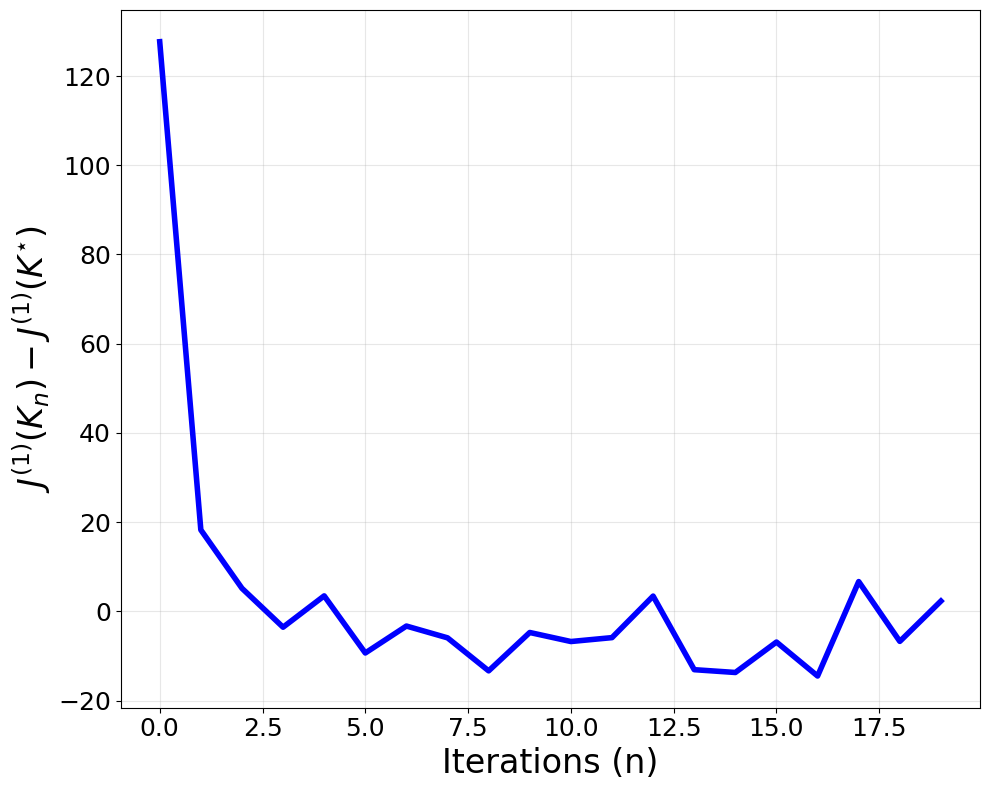

J*(eval): 5.625e+01  |  J_learned(eval): 4.785e+01


In [10]:
# Model-free LQR (pure rollout-based): zero-order policy gradient on K
# Loss weights for learning (not DARE's Q/R). Keep simple and well-conditioned.
Q_learn = np.eye(Nx)
R_learn = 1e-2 * np.eye(Nu)

# Batch sampler for initial states around hover (no attitude error)
def sample_x0_batch(batch_size=8, pos_scale=0.05, vel_scale=0.1, angvel_scale=0.1):
    batch = []
    for _ in range(batch_size):
        x0 = np.copy(xg)
        # small perturbations around hover
        x0[0:3] = x0[0:3] + np.random.uniform(-pos_scale, pos_scale, size=3)
        # zero attitude error quaternion
        x0[3:7] = rptoq(np.array([0.0, 0.0, 0.0]))
        x0[7:10] = x0[7:10] + np.random.uniform(-vel_scale, vel_scale, size=3)
        x0[10:13] = x0[10:13] + np.random.uniform(-angvel_scale, angvel_scale, size=3)
        batch.append(x0)
    return batch

# Single rollout cost
def rollout_cost(K, x0, horizon=300, uhover=None, clip=1e6):
    x = np.copy(x0)
    total = 0.0
    for t in range(horizon):
        delta = delta_x_quat(x, t*h)
        u = -K @ delta
        if uhover is not None:
            u_cmd = np.clip(
                uhover + u,
                np.array([-1*uhover[0]] * Nu) + uhover,
                np.array([1.0 - uhover[0]] * Nu) + uhover
            )
        else:
            u_cmd = u
        x = quad_dynamics_rk4(x, u_cmd)
        total += float(delta.T @ Q_learn @ delta + u.T @ R_learn @ u)
        if not np.isfinite(total) or np.linalg.norm(x) > clip:
            return clip
    return total

# Batch-averaged rollout cost
def rollout_cost_batch(K, x0_batch, horizon=300, uhover=None, clip=1e6):
    costs = [rollout_cost(K, x0, horizon, uhover, clip) for x0 in x0_batch]
    return float(np.mean(costs))

# Two-sided zero-order gradient (batched over x0)
def grad_zo_model_free(K, x0_batch, r=0.01, ns=20, horizon=300):
    nu, nx = K.shape
    grad = np.zeros_like(K)
    for _ in range(ns):
        U = np.random.randn(nu, nx)
        U = r * U / np.linalg.norm(U, 'fro')
        Jp = rollout_cost_batch(K + U, x0_batch, horizon, uhover)
        Jm = rollout_cost_batch(K - U, x0_batch, horizon, uhover)
        grad += ((nx * nu) / (2 * r * r)) * (Jp - Jm) * U
    return grad / ns

# Training loop with backtracking and simple scheduling
def model_free_lqr(K_init=None, lr=3e-4, max_iterations=300, r=0.003, ns=64,
                   horizon=600, batch_size=8, verbose=True, decay_every=50,
                   lr_decay=0.5, r_decay=0.7):
    K = (np.random.randn(Nu, Nx) * 0.01) if K_init is None else K_init.copy()
    costs = []
    for it in range(max_iterations):
        x0_batch = sample_x0_batch(batch_size=batch_size)
        J = rollout_cost_batch(K, x0_batch, horizon, uhover)
        costs.append(J)

        g = grad_zo_model_free(K, x0_batch, r=r, ns=ns, horizon=horizon)

        step = lr
        for _ in range(6):
            K_new = K - step * g
            J_new = rollout_cost_batch(K_new, x0_batch, horizon, uhover)
            if np.isfinite(J_new) and J_new <= J + 1e-6:
                K = K_new
                break
            step *= 0.5

        if (it + 1) % decay_every == 0:
            lr *= lr_decay
            r *= r_decay

        if verbose:
            print(f"iter {it}: J={J:.3e} step={step:.2e} lr={lr:.2e} r={r:.3e}")

    return K, costs

def model_free_lqr_fast(K_init=None, lr=5e-4, max_iterations=50):
    """Much faster version with adaptive hyperparameters"""
    
    K = K_init.copy() if K_init is not None else np.random.randn(Nu, Nx) * 0.01
    costs = []
    
    for it in range(max_iterations):
        # Start small, grow gradually
        ns = 8 + int(8 * it / max_iterations)  # 8→16 samples
        horizon = 100 + int(200 * it / max_iterations)  # 100→300 steps
        batch_size = 3 + int(2 * it / max_iterations)  # 3→5 batch
        
        # Early stopping for bad controllers
        x0_batch = sample_x0_batch(batch_size=batch_size)
        J = rollout_cost_batch(K, x0_batch, horizon, uhover)
        
        if J >= 1e6:  # Skip expensive gradient if controller is terrible
            K = K + np.random.randn(*K.shape) * 0.01  # Random perturbation
            continue
            
        costs.append(J)
        
        # Faster gradient estimation
        g = grad_zo_model_free(K, x0_batch, r=0.01, ns=ns, horizon=horizon)
        
        # Simple update (skip expensive backtracking)
        K = K - lr * g
        
        if it % 5 == 0:
            print(f"iter {it}: J={J:.2e} ns={ns} h={horizon}")
    
    return K, costs


# Warm-start close to optimal K* to encourage stable refinement
K0 = K_optimal.copy() + 0.22 * np.random.rand(Nu, Nx)


K_learned, costs = model_free_lqr(
    K_init=K0,
    lr=5e-4,
    max_iterations=20,      # ← Reduce from 300
    r=0.01,
    ns=16,                  # ← Reduce from 64  
    horizon=200,            # ← Reduce from 600
    batch_size=4,           # ← Reduce from 8
    decay_every=20,
    lr_decay=0.7,
    r_decay=0.8,
    verbose=True
)

# Plot J(K_n) - J(K*) using a fixed evaluation batch (like MAML plot)
# Use the same evaluation horizon/batch as above for fair comparison
h_eval = 200
b_eval = 4
x0_eval_batch = sample_x0_batch(batch_size=b_eval)
J_opt_eval = rollout_cost_batch(K_optimal, x0_eval_batch, h_eval, uhover)

costs_diff = np.array(costs, dtype=float) - J_opt_eval

plt.figure(figsize=(10,8))
plt.plot(np.arange(len(costs_diff)), costs_diff, color='blue', linewidth=4)
plt.ylabel(r'$J^{(1)}(K_{n}) - J^{(1)}(K^{\star})$', fontsize=24)
plt.xlabel('Iterations (n)', fontsize=24)
plt.tick_params(axis='both', labelsize=18)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"J*(eval): {J_opt_eval:.3e}  |  J_learned(eval): {rollout_cost_batch(K_learned, x0_eval_batch, h_eval, uhover):.3e}")


In [26]:
K_learned

array([[-2.0014,  1.9428,  4.3232, -1.2229, -1.2466, -0.8279, -0.5239,
         0.553 ,  0.8413,  0.0454, -0.073 , -0.1079],
       [ 2.0634,  1.9375,  4.5123, -1.1003,  1.394 ,  0.993 ,  0.7012,
         0.5525,  0.8234,  0.1735,  0.2407,  0.3013],
       [ 1.9809, -1.8393,  4.454 ,  1.3655,  1.19  , -0.8744,  0.5561,
        -0.4496,  0.8481,  0.166 ,  0.0708, -0.2315],
       [-1.6848, -1.6338,  4.5033,  1.4097, -1.0311,  0.9321, -0.3784,
        -0.3839,  0.8249,  0.2535,  0.1199,  0.4581]])

In [27]:
# Override QuadrotorController to support 'Pure LQR' (no TinyMPC)
class QuadrotorController:
    """Wrapper class for quadrotor controllers.
    
    Args:
        name: Display name for the controller (used in plots and logs)
        controller_type: 'tinympc' or 'lqr' to determine control method
        A, B, Q, R: System and cost matrices
        K_manual: Optional manual gain matrix (required for some controller types)
    """
    
    def __init__(self, name, controller_type, A, B, Q, R, K_manual=None):
        self.name = name  # Display name for plots/logs
        self.controller_type = controller_type  # 'tinympc' or 'lqr'
        self.A = A
        self.B = B
        self.Q = Q
        self.R = R
        
        self.N = 25
        self.rho = 5.0
        
        input_data = {
            'rho': self.rho,
            'A': A,
            'B': B,
            'Q': Q,
            'R': R
        }
        
        if controller_type == 'tinympc':
            # TinyMPC controller (with or without K seeding)
            if K_manual is None:
                # Standard TinyMPC with computed K_inf
                self.tinympc = TinyMPC(input_data, self.N)
            else:
                # TinyMPC seeded with provided K_manual
                K_manual = np.array(K_manual, dtype=float)
                self.tinympc = TinyMPC(input_data, self.N, K_manual=K_manual)
            
            self.K_used = self.tinympc.cache['Kinf']
            
            # Set bounds for TinyMPC
            u_max = [1.0-uhover[0]] * Nu
            u_min = [-1*uhover[0]] * Nu
            x_max = [2.] * Nx
            x_min = [-2.0] * Nx
            self.tinympc.set_bounds(u_max, u_min, x_max, x_min)
            
        elif controller_type == 'lqr':
            # Pure LQR controller (direct u = -K*x)
            self.tinympc = None
            
            if K_manual is not None:
                # Use provided K matrix
                self.K_used = np.array(K_manual, dtype=float)
            elif 'K_optimal' in globals():
                # Use pre-computed optimal K if available
                self.K_used = np.array(K_optimal, dtype=float)
            else:
                raise ValueError("K_manual required for LQR controller when K_optimal not available")
        else:
            raise ValueError(f"Unknown controller_type: {controller_type}. Must be 'tinympc' or 'lqr'")
        
        print(f"Controller '{self.name}' ({self.controller_type}) initialized with K norm: {np.linalg.norm(self.K_used):.4f}")

    def get_control(self, x_curr, t):
        """Compute control input for current state and time
        
        Args:
            x_curr: Current state
            t: Current time
            
        Returns:
            u_cmd: Control input
            iterations: Number of iterations (1 for LQR)
            status: Status code (1 for success)
        """
        # Get state error relative to reference
        delta_x = delta_x_quat(x_curr, t)
        
        if self.controller_type == 'lqr':
            # Pure LQR: u = -K*x
            u = -self.K_used @ delta_x
            u_cmd = np.clip(
                uhover + u,
                np.array([-1*uhover[0]] * Nu) + uhover,
                np.array([1.0 - uhover[0]] * Nu) + uhover
            )
            return u_cmd, 1, 1
        
        else:  # tinympc
            # Generate reference trajectory for horizon
            x_ref = np.zeros((Nx, self.N))
            u_ref = np.zeros((Nu, self.N-1))
            for i in range(self.N):
                x_ref[:, i] = generate_figure8_reference(t + i*h)
            u_ref[:] = uhover.reshape(-1,1)
            
            # Initialize with current state error
            x_init = np.copy(self.tinympc.x_prev)
            x_init[:, 0] = delta_x
            u_init = np.copy(self.tinympc.u_prev)
            
            # Solve TinyMPC optimization
            x_out, u_out, status, iterations = self.tinympc.solve_admm(
                x_init, u_init, x_ref, u_ref, current_time=t
            )
            return uhover + u_out[:,0], iterations, status

def simulate_controller(controller, x0, T_sim, dt=0.02):
    """Simulate controller for specified time duration
    
    Args:
        controller: QuadrotorController instance
        x0: Initial state (13D with quaternion)
        T_sim: Total simulation time
        dt: Time step (default: 0.02)
    
    Returns:
        x_traj, u_traj, iterations, status
    """
    NSIM = int(T_sim / dt)
    # Use Nx1 (13) for state dimension with quaternion, not Nx (12) for error coordinates
    x_traj = np.zeros((Nx1, NSIM+1))
    u_traj = np.zeros((Nu, NSIM))
    iterations = np.zeros(NSIM)
    status = np.zeros(NSIM)
    
    # Initial state is in full state coordinates (13D with quaternion)
    x_traj[:, 0] = x0
    
    print(f"Simulating '{controller.name}' ({controller.controller_type}) for {T_sim}s ({NSIM} steps)...")
    
    for i in range(NSIM):
        if i % 50 == 0:
            print(f"  Step {i}/{NSIM-1}, t={i*dt:.2f}s")
            
        t = i * dt
        u_curr, iter_count, status_code = controller.get_control(x_traj[:, i], t)
        x_traj[:, i+1] = quad_dynamics_rk4(x_traj[:, i], u_curr)
        
        u_traj[:, i] = u_curr
        iterations[i] = iter_count
        status[i] = status_code
    
    print("  Simulation completed!")
    print(f"  Average iterations: {np.mean(iterations):.1f}")
    print(f"  Convergence rate: {100 * np.sum(status == 1) / NSIM:.1f}%")
    
    return x_traj, u_traj, iterations, status


CREATING CONTROLLERS
Controller 'Optimal LQR' (lqr) initialized with K norm: 11.3295
Controller 'Learned LQR' (lqr) initialized with K norm: 11.3645

Controllers created successfully!

RUNNING SIMULATIONS
Simulating 'Optimal LQR' (lqr) for 8.0s (400 steps)...
  Step 0/399, t=0.00s
  Step 50/399, t=1.00s
  Step 100/399, t=2.00s
  Step 150/399, t=3.00s
  Step 200/399, t=4.00s
  Step 250/399, t=5.00s
  Step 300/399, t=6.00s
  Step 350/399, t=7.00s
  Simulation completed!
  Average iterations: 1.0
  Convergence rate: 100.0%
Simulating 'Learned LQR' (lqr) for 8.0s (400 steps)...
  Step 0/399, t=0.00s
  Step 50/399, t=1.00s
  Step 100/399, t=2.00s
  Step 150/399, t=3.00s
  Step 200/399, t=4.00s
  Step 250/399, t=5.00s
  Step 300/399, t=6.00s
  Step 350/399, t=7.00s
  Simulation completed!
  Average iterations: 1.0
  Convergence rate: 100.0%


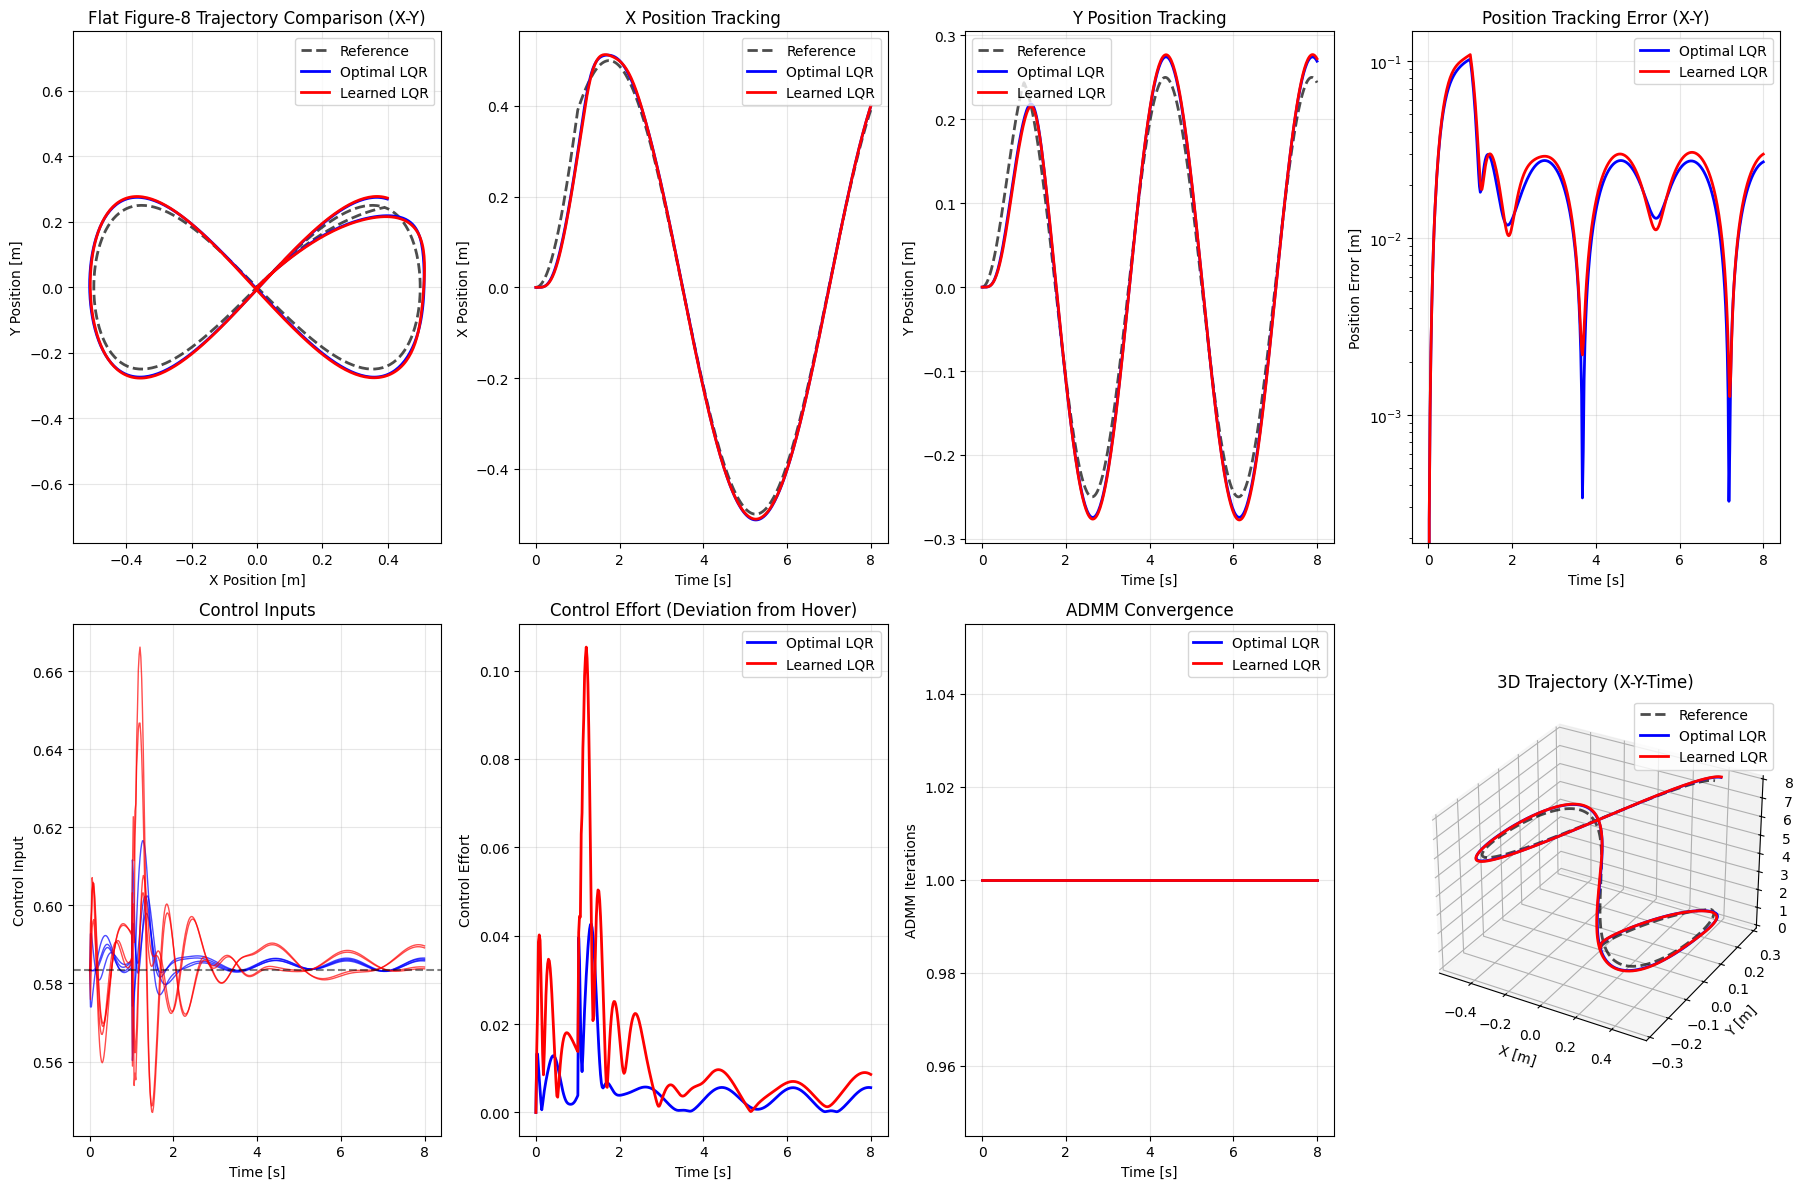

In [31]:
# Create and simulate different controllers
print("=" * 60)
print("CREATING CONTROLLERS")
print("=" * 60)

# Create controllers with new signature: name, controller_type, A, B, Q, R, K_manual=None
controllers = [
    # Standard TinyMPC with computed K_inf
    #QuadrotorController('Baseline TinyMPC', 'tinympc', Anp, Bnp, Q, R),
    
    # Pure LQR with optimal K
    QuadrotorController('Optimal LQR', 'lqr', Anp, Bnp, Q, R),
    
    # Pure LQR with learned K
    QuadrotorController('Learned LQR', 'lqr', Anp, Bnp, Q, R, K_manual=K_learned)
]

print("\nControllers created successfully!")

# Simulation setup
print("\n" + "=" * 60)
print("RUNNING SIMULATIONS")
print("=" * 60)

x0_sim = np.copy(xg)
x0_sim[0:3] = np.array([0.0, 0.0, 0.0])
x0_sim[3:7] = rptoq(np.array([0.0, 0.0, 0.0]))
T_sim = 8.0

# Run all simulations
results = []
for controller in controllers:
    results.append(simulate_controller(controller, x0_sim, T_sim))

# Use flexible plotting function with controller names
errors, efforts = create_comprehensive_plots(
    results,
    T_sim,
    labels=[controller.name for controller in controllers],
    colors=['b', 'r', 'g', 'm']
)


In [32]:
K_optimal

array([[-2.0185,  2.0307,  4.3875, -1.3113, -1.3535, -0.9596, -0.5188,
         0.5184,  0.7277, -0.0504, -0.06  , -0.2631],
       [ 1.9026,  1.9162,  4.3875, -1.1657,  1.2705,  0.9585,  0.4874,
         0.483 ,  0.7277, -0.0344,  0.0569,  0.2626],
       [ 2.0228, -2.0326,  4.3875,  1.2489,  1.197 , -0.9559,  0.5093,
        -0.5146,  0.7277,  0.0375,  0.0277, -0.2614],
       [-1.907 , -1.9143,  4.3875,  1.2282, -1.1141,  0.9569, -0.4779,
        -0.4868,  0.7277,  0.0473, -0.0246,  0.2619]])